# **프로젝트: CAM vs. Grad-CAM**

### **프로젝트 개요**
#### **1. 프로젝트 목적:**

CAM(Class Activation Mapping)과 Grad-CAM 두 XAI 기법을 직접 구현하고 Stanford Dogs 데이터셋으로 학습시켜, 분류 모델이 이미지의 어느 영역을 근거로 예측하는지를 히트맵과 바운딩 박스로 시각화하고 성능을 정량 평가한다.

#### **2. 데이터셋: [Stanford Dogs](http://vision.stanford.edu/aditya86/ImageNetDogs/main.html) 🐶**
- 120개 견종, 약 20,580장의 이미지로 구성된 fine-grained 이미지 분류 벤치마크 데이터셋

- 각 이미지에 품종 레이블과 바운딩 박스 GT(Ground Truth) annotation 포함

- ImageNet 사전 학습 정규화(mean/std) 및 224×224 리사이즈 적용


#### **3. 모델: ResNet-50**
CAM과 Grad-CAM을 동일한 ResNet-50 백본으로 구현해 공정하게 비교한다.
- ImageNet 사전 학습 가중치 사용, 마지막 FC 레이어만 120종 출력으로 교체
  
- CAM 논문 구조: layer4 → GAP → FC(softmax)

- **평가 지표:**
  * IoU(Intersection over Union): 위치 추정(localization) 성능 측정
  * F1-score · Accuracy · Precision · Recall로 분류(Classification) 성능 측정

#### **4. 추가 실험:**
- FC 레이어의 bias 항 유무가 분류 성능과 위치 추정 성능에 미치는 영향을 실험 및 분석한다.

- `bias=True` vs `bias=False(CAM 논문 방식)` 두 모델을 동일한 조건(seed, lr, epoch)에서 학습

- Accuracy와 IoU 평가지표로 분류-위치 추정 간 trade-off를 정량 비교

## 1. 라이브러리 불러오기 & 경로 설정

In [1]:
import os
import shutil
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # 폰트 관리
import numpy as np
import cv2
import torch.nn.functional as F
import xml.etree.ElementTree as ET
import random
import PIL
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print(torch.__version__)
print(np.__version__)
print(cv2.__version__)
print(PIL.__version__)

2.7.1+cu118
2.2.6
4.13.0
11.2.1


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # 디바이스 설정
print(device)

cuda


In [3]:
HOME = os.getenv('HOME')
PROJECT_DIR = os.path.join(HOME, 'work/class_activation_map')

images_dir      = os.path.join(PROJECT_DIR, 'Images')
annotation_dir  = os.path.join(PROJECT_DIR, 'Annotation')
train_mat_path  = os.path.join(PROJECT_DIR, 'train_list.mat')
test_mat_path   = os.path.join(PROJECT_DIR, 'test_list.mat')
cam_model_path  = os.path.join(PROJECT_DIR, 'cam_model.pt')

train_mat = sio.loadmat(train_mat_path)
test_mat  = sio.loadmat(test_mat_path)

train_file_list = train_mat['file_list']
test_file_list  = test_mat['file_list']

base_dir  = 'stanford_dogs'
train_dir = os.path.join(base_dir, 'train')
test_dir  = os.path.join(base_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir,  exist_ok=True)

## 2. 사용자 정의 함수

In [4]:
def set_seed(seed: int = 42):
    """
    재현성을 위한 난수 고정 함수.
    Python / NumPy / PyTorch (CPU & GPU) 난수를 모두 고정한다.
    """
    random.seed(seed) # Python 내장 random 모듈 고정
    np.random.seed(seed) # Numpy 연산 고정 (데이터 셔플 등)
    torch.manual_seed(seed) # CPU 텐서 연산 고정
    torch.cuda.manual_seed(seed) # 모든 GPU 고정
    torch.cuda.manual_seed_all(seed)   # 멀티 GPU 대비
    torch.backends.cudnn.deterministic = True # cuDNN이 항상 동일한 알고리즘을 선택하도록 강제
    torch.backends.cudnn.benchmark     = False # 실행 시마다 최적 알고리즘이 동일하게 선택되도록 함

set_seed(42) # 난수 고정

In [5]:
def process_mat_file(file_list_array, split_dir):
    """
    .mat 파일의 file_list_array를 읽어 split_dir에 클래스별 폴더를 만들고 이미지를 복사합니다.
    """
    for idx in range(file_list_array.shape[0]):
        file_path = file_list_array[idx][0].item()
        if isinstance(file_path, bytes):
            file_path = file_path.decode('utf-8')

        class_folder = file_path.split('/')[0]
        dest_folder  = os.path.join(split_dir, class_folder)
        os.makedirs(dest_folder, exist_ok=True)

        src_path  = os.path.join(images_dir, file_path)
        dest_path = os.path.join(dest_folder, os.path.basename(file_path))

        if os.path.exists(src_path):
            shutil.copy(src_path, dest_path)
        else:
            print(f'File not found: {src_path}')

print('Processing train set...')
process_mat_file(train_file_list, train_dir)
print('Processing test set...')
process_mat_file(test_file_list, test_dir)
print('Dataset reorganization complete.')

Processing train set...
Processing test set...
Dataset reorganization complete.


In [6]:
# 헬퍼 함수
# 정규화된 텐서 → uint8 numpy 이미지

MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def unnormalize(img_tensor):
    """
    정규화된 이미지 텐서를 시각화 가능한 uint8 배열로 복원하는 함수

    학습 시 적용한 ImageNet 정규화(mean/std)를 역산해서
    픽셀값을 0~255 범위의 numpy 배열로 변환한다.
    
    시각화(imshow, cv2)에 넘기기 전에 호출 권장.

    img_tensor : [C, H, W] CPU/GPU 텐서
    return     : [H, W, C] uint8 ndarray (0-255)
    """
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = np.clip(STD * img + MEAN, 0, 1)
    return (img * 255).astype(np.uint8)


def visualize(sample, dataset=None):
    if dataset is None:
        dataset = train_dataset

    img_tensor, label, bbox = sample
    print(f'Label index : {label}')
    print(f'Class name  : {dataset.classes[label]}')

    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = np.clip(STD * img_np + MEAN, 0, 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_np)
    plt.title(f'Class: {dataset.classes[label]}')
    plt.axis('off')
    plt.show()

In [7]:
def train_model(model, train_loader, valid_loader, criterion, optimizer,
                num_epochs=2, scheduler=None):
    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        print(f'\nEpoch {epoch+1}/{num_epochs} 시작')

        for batch_idx, (images, labels, _) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds       = outputs.argmax(dim=1)
            total      += labels.size(0)
            correct    += (preds == labels).sum().item()

            if (batch_idx + 1) % 50 == 0:
                print(f'  Step {batch_idx+1} - Loss: {loss.item():.4f}')

        print(f'Train - Loss: {train_loss/(batch_idx+1):.4f}, Accuracy: {correct/total*100:.2f}%')

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels, _ in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                preds    = outputs.argmax(dim=1)
                total   += labels.size(0)
                correct += (preds == labels).sum().item()

        print(f'Validation - Loss: {val_loss/len(valid_loader):.4f}, Accuracy: {correct/total*100:.2f}%')

        # Scheduler
        if scheduler is not None:
            scheduler.step()
            print(f'  LR: {scheduler.get_last_lr()[0]:.6f}')

In [8]:
def build_model(use_bias: bool, num_classes: int, device):
    """ResNet50 + GAP + FC 모델 생성. use_bias로 fc bias 유무 제어."""
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes, bias=use_bias)
    return m.to(device)

In [9]:
def compute_accuracy(model, loader, device):
    """validation set 전체 정확도 반환."""
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels, _ in loader:
            images, labels = images.to(device), labels.to(device)
            preds    = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total

In [10]:
def compute_mean_iou(model, dataset, n_samples, threshold, device):
    """
    배치 추론으로 CAM 기반 Mean IoU를 계산하는 함수

    dataset에서 n_samples개를 뽑아 DataLoader로 CAM 기반 bbox IoU 평균을 반환한다.
    샘플마다 CAM을 생성하고 threshold로 이진화해 예측 bbox를 구한 뒤,
    annotation의 GT bbox와 IoU를 계산해 평균을 반환.
    annotation이 없는 샘플(bbox 전부 0.0)은 자동으로 건너뜀

    model     : 평가할 CAM 모델 (GAP + FC 구조)
    dataset   : StanfordDogsDatasetWithBBox
    n_samples : IoU 계산에 사용할 샘플 수
    threshold : CAM 이진화 임계값 (0~1)
    device    : 추론 디바이스
    return    : float, 유효 샘플들의 평균 IoU
    """
    ious = []
    for idx in range(min(n_samples, len(dataset))):
        image, _, ground_bbox = dataset[idx]

        # annotation이 없는 샘플 스킵
        if all(v == 0.0 for v in ground_bbox):
            continue

        sample_img  = image.unsqueeze(0).to(device)
        orig        = unnormalize(image)

        cam         = generate_cam(model, sample_img)
        cam_resized = cv2.resize(cam, (orig.shape[1], orig.shape[0]))
        pred_bbox   = get_bbox(cam_resized, threshold_ratio=threshold)
        gt_bbox     = tuple(int(x) for x in ground_bbox)

        ious.append(get_iou(pred_bbox, gt_bbox))

    return float(np.mean(ious)) if ious else 0.0

In [11]:
def plot_tradeoff(acc_bias, acc_no_bias, iou_bias, iou_no_bias):
    """
    [추가 실험]
    bias=True / False 두 모델의 Accuracy와 Mean IoU를 비교하는 함수
    - 왼쪽 바 차트 : Accuracy 비교
    - 오른쪽 바 차트: Mean IoU 비교
    - 두 지표를 겹친 라인 차트로 트레이드오프 방향을 강조
    """
    labels   = ['bias=True\n', 'bias=False\n']
    accs     = [acc_bias,    acc_no_bias]
    ious     = [iou_bias,    iou_no_bias]
    colors_a = ['#E07B54', '#5B9BD5']
    colors_i = ['#E07B54', '#5B9BD5']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('bias=True vs bias=False : Accuracy & IoU Trade-off', fontsize=14, fontweight='bold')

    # 1) Accuracy bar
    bars = axes[0].bar(labels, accs, color=colors_a, edgecolor='white', width=0.45)
    axes[0].set_title('Classification Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1.0)
    for bar, v in zip(bars, accs):
        axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                     f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # 2) IoU bar
    bars = axes[1].bar(labels, ious, color=colors_i, edgecolor='white', width=0.45)
    axes[1].set_title('Mean IoU (CAM Localization)')
    axes[1].set_ylabel('Mean IoU')
    axes[1].set_ylim(0, 1.0)
    for bar, v in zip(bars, ious):
        axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                     f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # 3) trade-off 꺾은선
    x = [0, 1]
    axes[2].plot(x, accs, 'o-', color='#E07B54', linewidth=2, markersize=9, label='Accuracy')
    axes[2].plot(x, ious, 's--', color='#5B9BD5', linewidth=2, markersize=9, label='Mean IoU')

    # 변화량 화살표 annotation
    delta_acc = acc_no_bias - acc_bias
    delta_iou = iou_no_bias - iou_bias
    axes[2].annotate(
        f'Δ Acc {delta_acc:+.4f}',
        xy=(1, acc_no_bias), xytext=(1.05, acc_no_bias),
        fontsize=9, color='#E07B54',
        arrowprops=dict(arrowstyle='->', color='#E07B54', lw=1.2),
    )
    axes[2].annotate(
        f'Δ IoU {delta_iou:+.4f}',
        xy=(1, iou_no_bias), xytext=(1.05, iou_no_bias),
        fontsize=9, color='#5B9BD5',
        arrowprops=dict(arrowstyle='->', color='#5B9BD5', lw=1.2),
    )

    axes[2].set_xticks(x)
    axes[2].set_xticklabels(['bias=True', 'bias=False'])
    axes[2].set_ylim(0, 1.0)
    axes[2].set_title('Trade-off Overview')
    axes[2].legend(loc='upper left')
    axes[2].grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # 수치 요약 표
    print()
    print(f'{"":20} {"bias=True":>12} {"bias=False":>12} {"Δ (False-True)":>15}')
    print('-' * 62)
    print(f'{"Accuracy":20} {acc_bias:>12.4f} {acc_no_bias:>12.4f} {acc_no_bias-acc_bias:>+15.4f}')
    print(f'{"Mean IoU":20} {iou_bias:>12.4f} {iou_no_bias:>12.4f} {iou_no_bias-iou_bias:>+15.4f}')

In [12]:
def overlay(cam_resized, img, alpha=0.5):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(heatmap, alpha, img, 1 - alpha, 0)

In [13]:
def generate_cam(model, image):
    """
    CAM(Class Activation Map)을 생성하는 함수

    [Zhou et al., CVPR 2016 - Eq.(2)]
        M_c(x,y) = Σ_k  w_k^c  *  f_k(x, y)
        - f_k(x,y) : last conv layer(layer4)의 k번째 feature map
        - w_k^c    : class c에 대한 fc layer의 k번째 가중치

    모델 구조: Conv → GAP → FC(softmax, bias=0)
    hook 위치: layer4 (avgpool 이전 마지막 conv block)

    return: [H, W] float ndarray, 값 범위 [0, 1]
    """
    model.eval()
    features = []

    handle = model.layer4.register_forward_hook(
        lambda m, i, o: features.append(o.detach())
    )
    with torch.no_grad():
        output = model(image)
    handle.remove()

    pred_class = output.argmax(dim=1).item()
    fc_weights = model.fc.weight.data          # [num_classes, C]
    fmap       = features[0][0]                # [C, H, W]  — 7×7 spatial grid

    # 논문 Eq.(2): 클래스 가중치와 feature map의 가중합
    cam = (fc_weights[pred_class].unsqueeze(-1).unsqueeze(-1) * fmap).sum(dim=0)
    cam = cam.cpu().numpy()

    # 논문과 동일하게 ReLU(음수 제거) 후 정규화
    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

In [14]:
def visualize_cam(cam, title='CAM'):
    plt.figure(figsize=(6, 6))
    plt.imshow(cam, cmap='jet')
    plt.colorbar()
    plt.title(title)
    plt.axis('off')
    plt.show()

In [15]:
def visualize_cam_on_image(cam, img, alpha=0.5, title='CAM Overlay on Image'):
    """
    CAM 히트맵을 원본 이미지 위에 반투명하게 겹쳐서 출력하는 함수

    cam   : [H', W'] float ndarray, 값 범위 [0, 1]
    img   : [H, W, 3] uint8 ndarray
    alpha : heatmap 불투명도 (0=원본만, 1=히트맵만)
    """
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(heatmap, alpha, img, 1 - alpha, 0)

    plt.figure(figsize=(8, 8))
    plt.imshow(overlay)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [16]:
def generate_grad_cam(model, image, target_layer_name):
    """
    Grad-CAM을 생성하는 함수

    [Selvaraju et al., ICCV 2017 - Eq.(1)(2)]
        α_k^c = (1/Z) Σ_i Σ_j  ∂y^c / ∂A_k_ij   ← gradient GAP
        L^c_Grad-CAM = ReLU( Σ_k α_k^c * A_k )

    중요: y^c는 softmax 이전의 raw logit 값
    논문 발췌: "we first compute the gradient of the score for class c,
           y^c (before the softmax)"

    target_layer_name : 모델 내 레이어 이름 (예: 'layer4', 'layer3')
    return: [H, W] float ndarray, 값 범위 [0, 1]
    """
    model.eval()
    features, gradients = {}, {}

    target_layer = dict(model.named_modules()).get(target_layer_name)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    fwd_handle = target_layer.register_forward_hook(
        lambda m, i, o: features.update({'value': o})
    )
    bwd_handle = target_layer.register_full_backward_hook(
        lambda m, gi, go: gradients.update({'value': go[0].detach()})
    )

    output = model(image)                         # [1, num_classes]
    pred_class = output.argmax(dim=1).item()

    model.zero_grad()
    # softmax 이전 raw logit으로 backward
    # output은 fc 직후이므로 softmax가 적용되지 않은 logit 값
    # (nn.CrossEntropyLoss가 내부에서 softmax를 처리하므로 모델 출력은 logit)
    output[0, pred_class].backward()

    fwd_handle.remove()
    bwd_handle.remove()

    fmap    = features['value'][0]                         # [C, H, W]
    # gradient의 Global Average Pooling → 채널 중요도 가중치
    weights = gradients['value'][0].mean(dim=(1, 2))       # [C]

    # 가중합 후 ReLU (불필요한 노이즈 등 제거 효과)
    grad_cam = (weights.unsqueeze(-1).unsqueeze(-1) * fmap).sum(dim=0)
    grad_cam = F.relu(grad_cam).detach().cpu().numpy()
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)
    return grad_cam

In [17]:
# 히트맵 → 바운딩 박스 변환을 위한 전처리
# ① Threshold 이진화: 연속형 히트맵을 0/1 마스크로 변환해 관심 영역을 분리한다.
# ② Morphological 연산(Closing): 작은 구멍을 채우고 단절된 영역을 연결해 bbox 품질을 높인다.
# ③ argwhere로 활성 좌표의 min/max를 구하면 사각형 bbox를 얻을 수 있다.

def get_bbox(cam, threshold_ratio=0.2):
    """
    CAM에서 bounding box를 추출하는 함수

    [Zhou et al. (CAM), CVPR 2016]
        "we first segment the regions of which the value is above
         20% of the max value of the CAM"

    [Selvaraju et al. (Grad-CAM), ICCV 2017]
        "binarize them with a threshold of 15% of the max intensity"

    변환 파이프라인:
      1) max 비율 기반 threshold 이진화 (고정값 아닌 상대값)
      2) Morphological closing → 구멍 채우기 / 영역 연결
      3) 가장 큰 connected component 선택 (논문: 'the single largest segment')
      4) 해당 영역의 min/max 좌표 → (x_min, y_min, x_max, y_max)

    threshold_ratio : CAM max 값 대비 비율 (CAM 논문=0.2, Grad-CAM 논문=0.15)
    return: (x_min, y_min, x_max, y_max) 또는 None
    """
    # 상대적 threshold: 논문 방식 (max 값의 일정 비율)
    threshold = threshold_ratio * cam.max()
    binary = (cam > threshold).astype(np.uint8)

    # Morphological closing: 작은 구멍을 메워 연속 영역으로 만든다
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # Connected components → 가장 큰 영역 선택 (논문: 'the single largest segment')
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:   # 배경(0)만 있는 경우
        return None

    # stats 형식: [x, y, w, h, area] — label 0은 배경이므로 1부터
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    x = stats[largest_label, cv2.CC_STAT_LEFT]
    y = stats[largest_label, cv2.CC_STAT_TOP]
    w = stats[largest_label, cv2.CC_STAT_WIDTH]
    h = stats[largest_label, cv2.CC_STAT_HEIGHT]

    return (x, y, x + w, y + h)

In [18]:
def visualize_bbox_on_image(img, bbox, box_color=(255, 0, 0), thickness=2):
    """단일 bounding box를 이미지 위에 그리는 함수"""
    img_with_bbox = img.copy()
    if bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), box_color, thickness)
    else:
        print('활성화된 영역이 없습니다.')
    return img_with_bbox

In [19]:
def get_iou(bbox1, bbox2):
    """
    두 bounding box의 IoU(Intersection over Union)를 계산하는 함수
    bbox 형식: min-max
    """
    if bbox1 is None or bbox2 is None:
        return 0.0

    x_min1, y_min1, x_max1, y_max1 = bbox1
    x_min2, y_min2, x_max2, y_max2 = bbox2

    # 교집합 좌표
    ix_min, iy_min = max(x_min1, x_min2), max(y_min1, y_min2)
    ix_max, iy_max = min(x_max1, x_max2), min(y_max1, y_max2)

    inter_area = max(0, ix_max - ix_min) * max(0, iy_max - iy_min)
    area1      = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2      = (x_max2 - x_min2) * (y_max2 - y_min2)
    union_area = area1 + area2 - inter_area

    return inter_area / union_area if union_area > 0 else 0.0

In [20]:
def evaluate_classification(model, loader, device):
    """
    전체 데이터셋에 대해 Accuracy / Recall / Precision / F1-score를 계산하는 함수
    multi-class의 경우 macro average 사용
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device)
            preds  = model(images).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    print(f'Accuracy  : {acc:.4f}')
    print(f'Recall    : {rec:.4f}  (macro avg)')
    print(f'Precision : {prec:.4f}  (macro avg)')
    print(f'F1-score  : {f1:.4f}  (macro avg)')

    return {'accuracy': acc, 'recall': rec, 'precision': prec, 'f1': f1}

In [21]:
def visualize_both_bbox_on_image(img, bbox, ground_truth, thickness=2):
    """
    예측 bbox(파랑)와 ground truth bbox(초록)를 함께 시각화하는 함수
    """
    img_with_bbox = img.copy()

    x_min,   y_min,   x_max,   y_max   = bbox
    x_min_t, y_min_t, x_max_t, y_max_t = ground_truth

    cv2.rectangle(img_with_bbox, (x_min,   y_min),   (x_max,   y_max),   (255, 0, 0), thickness)  # 파랑: 예측
    cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)  # 초록: GT

    return img_with_bbox

## 3. 데이터 로드

In [22]:
class StanfordDogsDatasetWithBBox(datasets.ImageFolder):
    """
    ImageFolder를 상속해 Stanford Dogs의 bounding box annotation을 함께 반환
    반환: (image_tensor, label, bbox)  
    — bbox 형식: [xmin, ymin, xmax, ymax] (224x224 기준)
    """
    NEW_SIZE = (224, 224)  # (H, W)

    def __init__(self, root, annotation_root, transform=None):
        super().__init__(root, transform=transform)
        self.annotation_root = annotation_root

    def _parse_bbox(self, annot_path):
        """XML annotation 파일을 파싱해 리사이즈된 bbox를 반환"""
        tree = ET.parse(annot_path)
        root_xml = tree.getroot()

        obj    = root_xml.find('object')
        bndbox = obj.find('bndbox') if obj is not None else None
        size   = root_xml.find('size')

        if bndbox is None or size is None:
            return [0.0, 0.0, 0.0, 0.0]

        w, h   = float(size.find('width').text), float(size.find('height').text)
        new_h, new_w = self.NEW_SIZE
        scale_x, scale_y = new_w / w, new_h / h

        return [
            float(bndbox.find('xmin').text) * scale_x,
            float(bndbox.find('ymin').text) * scale_y,
            float(bndbox.find('xmax').text) * scale_x,
            float(bndbox.find('ymax').text) * scale_y,
        ]

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _      = self.samples[index]

        rel_path     = os.path.relpath(path, self.root)
        annot_name   = os.path.splitext(os.path.basename(rel_path))[0]
        annot_folder = os.path.dirname(rel_path)
        annot_path   = os.path.join(self.annotation_root, annot_folder, annot_name)

        bbox = [0.0, 0.0, 0.0, 0.0]
        if os.path.exists(annot_path):
            try:
                bbox = self._parse_bbox(annot_path)
            except Exception as e:
                print(f'Error parsing {annot_path}: {e}')
        else:
            print(f'Annotation file not found: {annot_path}')

        return image, label, bbox

In [23]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = StanfordDogsDatasetWithBBox(root=train_dir, annotation_root=annotation_dir, transform=transform)
valid_dataset = StanfordDogsDatasetWithBBox(root=test_dir,  annotation_root=annotation_dir, transform=transform)

batch_size   = 12
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print(f'Number of classes: {num_classes}')
print(f'Train samples    : {len(train_dataset)}')
print(f'Test samples     : {len(valid_dataset)}')

Number of classes: 120
Train samples    : 12000
Test samples     : 8580


Label index : 2
Class name  : n02085936-Maltese_dog


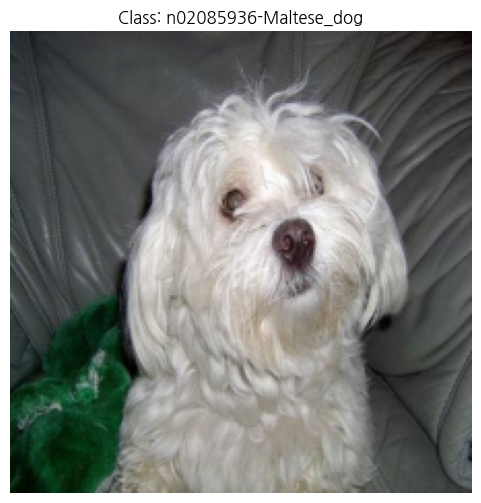

In [24]:
visualize(train_dataset[200]) # train 이미지 예시

Label index : 2
Class name  : n02085936-Maltese_dog


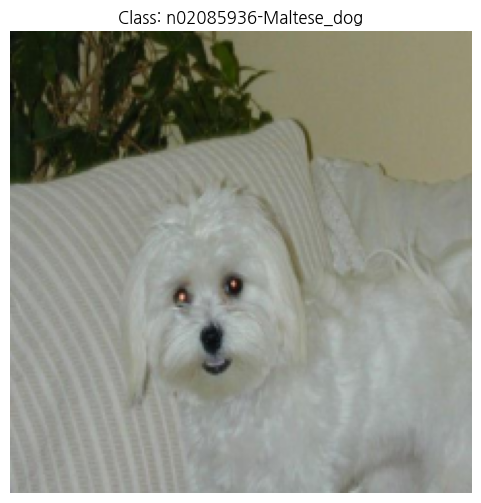

In [25]:
visualize(valid_dataset[200]) # 검증 이미지 예시

In [26]:
# Annotation XML 구조 확인
annotation_path = os.path.join(annotation_dir, 'n02085936-Maltese_dog/n02085936_37')
root_xml = ET.parse(annotation_path).getroot()
for elem in root_xml.iter():
    print(f'{elem.tag}: {elem.text}')

annotation: 
	
folder: 02085936
filename: n02085936_37
source: 
		
database: ImageNet database
size: 
		
width: 500
height: 375
depth: 3
segment: 0
object: 
		
name: Maltese_dog
pose: Unspecified
truncated: 0
difficult: 0
bndbox: 
			
xmin: 148
ymin: 13
xmax: 402
ymax: 336


## 4. 모델 정의

In [27]:
# 모델 구조: Conv layers → GAP → FC(softmax)
# ResNet50은 이미 layer4 → avgpool(GAP) → fc 구조이므로 fc만 교체
set_seed(42) # 모델 생성 시 난수 고정
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes, bias=True)
model = model.to(device)
model

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 223MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## 5. 모델 학습

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1) # 스케줄러 추가

In [29]:
%%time
train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2)


Epoch 1/2 시작
  Step 50 - Loss: 3.1125
  Step 100 - Loss: 1.9471
  Step 150 - Loss: 1.8828
  Step 200 - Loss: 1.9224
  Step 250 - Loss: 2.1963
  Step 300 - Loss: 1.6225
  Step 350 - Loss: 2.2829
  Step 400 - Loss: 1.9807
  Step 450 - Loss: 1.0677
  Step 500 - Loss: 3.5103
  Step 550 - Loss: 1.2361
  Step 600 - Loss: 1.7334
  Step 650 - Loss: 1.6076
  Step 700 - Loss: 2.0251
  Step 750 - Loss: 1.6760
  Step 800 - Loss: 1.4070
  Step 850 - Loss: 1.3366
  Step 900 - Loss: 1.1951
  Step 950 - Loss: 1.2742
  Step 1000 - Loss: 1.8581
Train - Loss: 1.8545, Accuracy: 50.00%
Validation - Loss: 1.3999, Accuracy: 60.06%

Epoch 2/2 시작
  Step 50 - Loss: 1.5793
  Step 100 - Loss: 0.8950
  Step 150 - Loss: 0.4624
  Step 200 - Loss: 0.8767
  Step 250 - Loss: 1.2023
  Step 300 - Loss: 1.3781
  Step 350 - Loss: 0.5161
  Step 400 - Loss: 1.0233
  Step 450 - Loss: 0.7809
  Step 500 - Loss: 1.1143
  Step 550 - Loss: 2.0449
  Step 600 - Loss: 0.5265
  Step 650 - Loss: 0.7521
  Step 700 - Loss: 0.7600
  Step

In [30]:
torch.save(model, cam_model_path)

## 6. XAI

### CAM 시각화

In [31]:
# 샘플 준비
image, label, bbox = train_dataset[10]
sample_image = image.unsqueeze(0).to(device)
orig_img     = unnormalize(image)

# 저장된 모델 불러오기
model = torch.load(cam_model_path, weights_only=False)

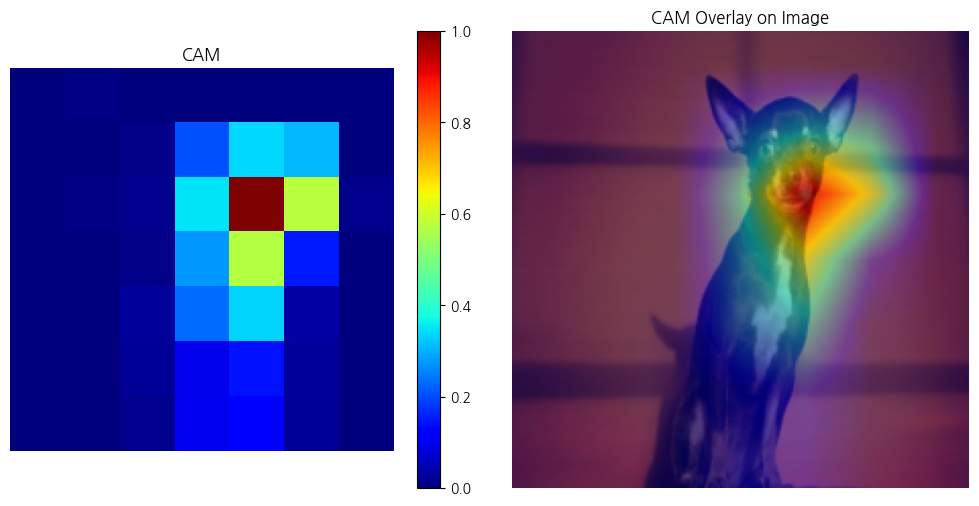

In [32]:
cam = generate_cam(model, sample_image)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 좌측에 CAM 히트맵
im = axes[0].imshow(cam, cmap='jet')
axes[0].set_title('CAM')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0])

# 우측에 CAM Overlay
cam_resized = cv2.resize(cam, (orig_img.shape[1], orig_img.shape[0]))
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
blended = cv2.addWeighted(heatmap, 0.5, orig_img, 0.5, 0)
axes[1].imshow(blended)
axes[1].set_title('CAM Overlay on Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Grad-CAM 시각화

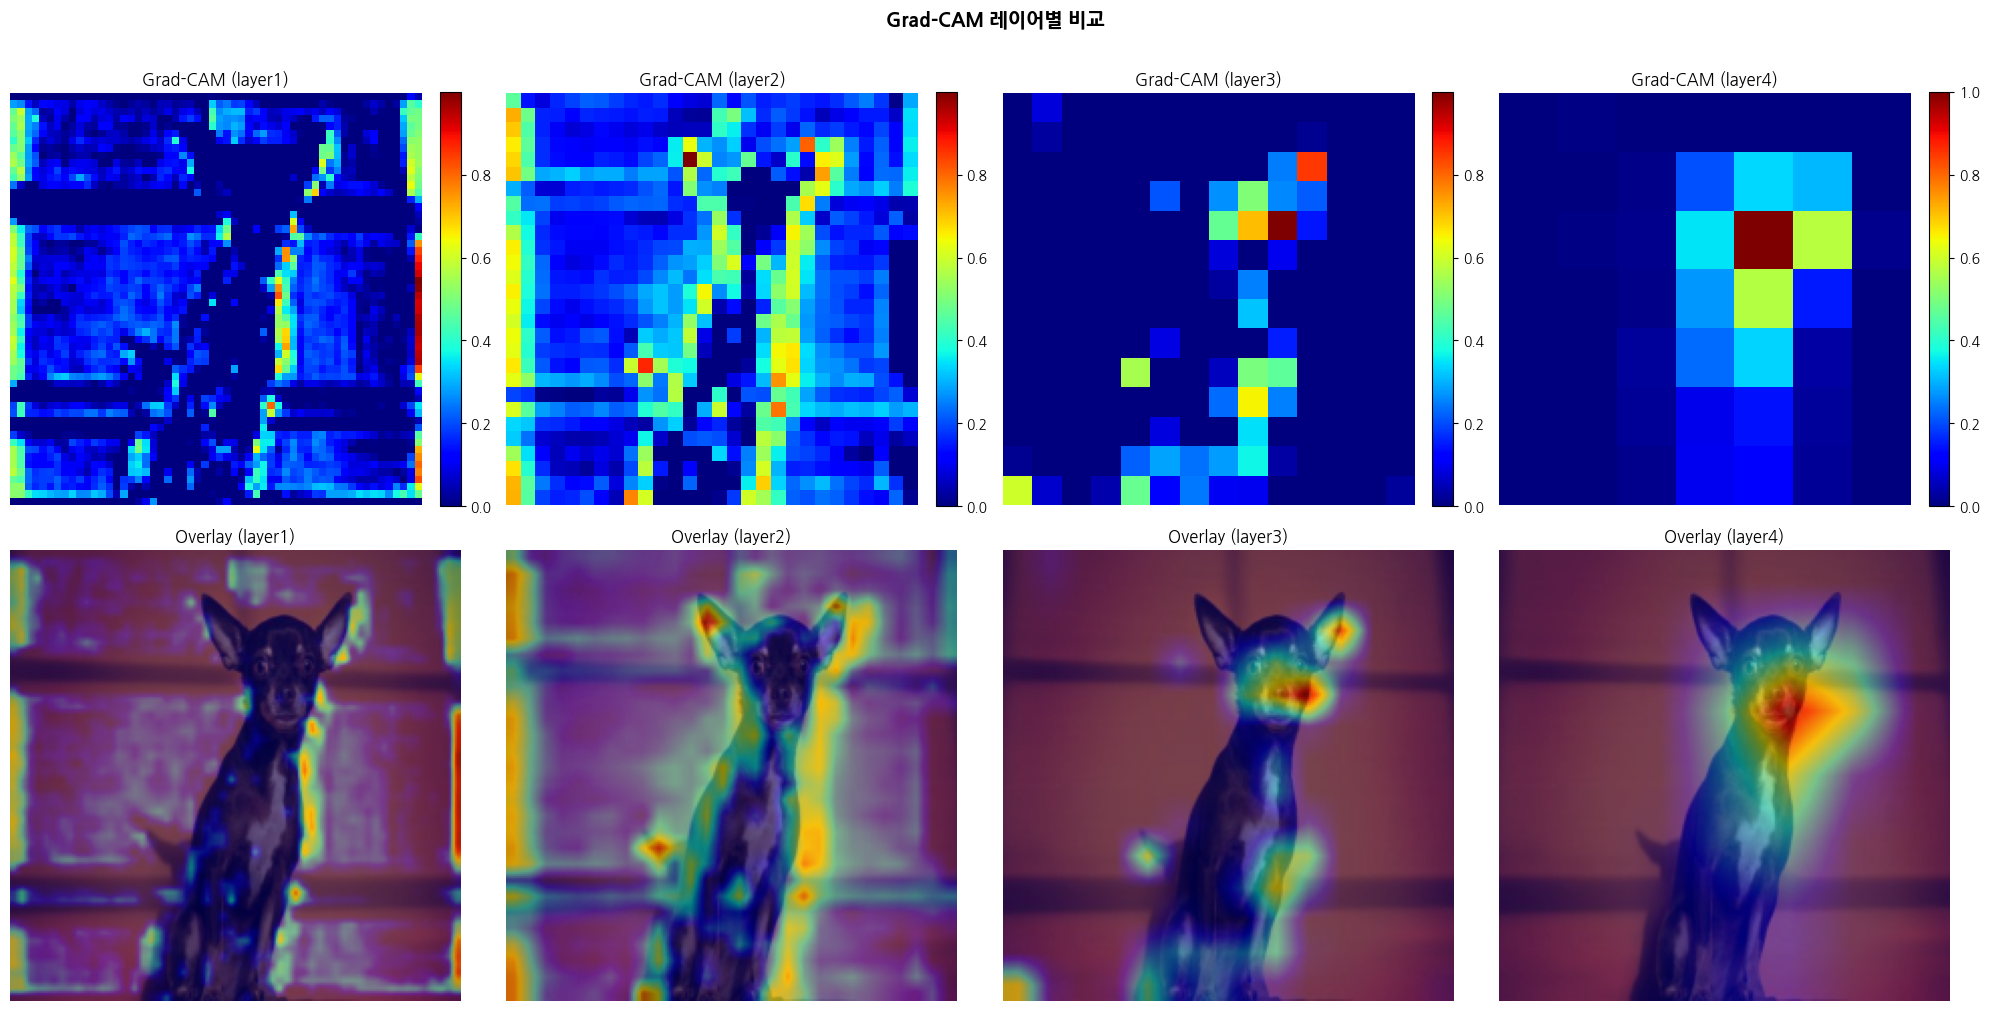

In [33]:
# 얕은 레이어(layer1)는 수용장(Receptive Field)이 작아 엣지·텍스처 같은 저수준 특징을 담으며 히트맵이 넓고 분산된다. 
# 깊은 레이어(layer4)로 갈수록 수용장이 커지고 고수준 의미 특징(개체 전체)에 반응하므로 히트맵이 객체에 집중(localized)되어 나타난다.
# 따라서 Object Localization 목적에는 layer4 Grad-CAM이 가장 적합함

layer_names = ['layer1', 'layer2', 'layer3', 'layer4']

# 레이어별 grad-cam 미리 계산
grad_cams = {
    layer: generate_grad_cam(model, sample_image, target_layer_name=layer)
    for layer in layer_names
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col, layer_name in enumerate(layer_names):
    grad_cam = grad_cams[layer_name]

    # 1행 Grad-CAM 히트맵
    im = axes[0][col].imshow(grad_cam, cmap='jet')
    axes[0][col].set_title(f'Grad-CAM ({layer_name})', fontsize=12)
    axes[0][col].axis('off')
    plt.colorbar(im, ax=axes[0][col], fraction=0.046, pad=0.04)

    # 2행 Overlay
    cam_resized = cv2.resize(grad_cam, (orig_img.shape[1], orig_img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    blended = cv2.addWeighted(heatmap, 0.5, orig_img, 0.5, 0)
    axes[1][col].imshow(blended)
    axes[1][col].set_title(f'Overlay ({layer_name})', fontsize=12)
    axes[1][col].axis('off')

plt.suptitle('Grad-CAM 레이어별 비교', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

layer1에서는 히트맵이 이미지 전체에 넓고 균일하게 분산되어 있다가, layer2와 3을 거치며 점차 특정 영역으로 좁혀지고, layer4에서는 개의 몸통과 얼굴 부위에 뚜렷하게 집중되는 것을 확인할 수 있다. 이는 layer1에서는 **수용장**이 작아 전체 이미지에 히트맵이 분산되고, layer4에서는 수용장이 이미지 대부분을 커버해 객체의 핵심 부위에 히트맵이 집중되었음을 뜻한다.

## 7. CAM vs Grad-CAM 비교

### 샘플 이미지 준비 및 CAM, Grad-CAM 생성

In [34]:
# 샘플 재선택
image, label, ground_bbox = train_dataset[100]
sample_image = image.unsqueeze(0).to(device)
orig_img = unnormalize(image)
ground_truth = tuple(int(x) for x in ground_bbox)

# CAM 생성 및 bbox 추출 (threshold = max값의 20%)
cam = generate_cam(model, sample_image)
cam_resized = cv2.resize(cam, (orig_img.shape[1], orig_img.shape[0]))
bbox = get_bbox(cam_resized, threshold_ratio=0.2)

# Grad-CAM 생성 및 bbox 추출 (threshold = max값의 15%)
grad_cam = generate_grad_cam(model, sample_image, target_layer_name='layer4')
grad_cam_resized = cv2.resize(grad_cam, (orig_img.shape[1], orig_img.shape[0]))
grad_cam_bbox = get_bbox(grad_cam_resized, threshold_ratio=0.15)

### IoU 비교

In [35]:
iou_cam = get_iou(bbox, ground_truth)
iou_grad_cam = get_iou(grad_cam_bbox, ground_truth)

print(f'CAM IoU: {iou_cam:.4f}  (threshold: 20% of max)')
print(f'Grad-CAM IoU: {iou_grad_cam:.4f}  (threshold: 15% of max)')

CAM IoU: 0.3626  (threshold: 20% of max)
Grad-CAM IoU: 0.3956  (threshold: 15% of max)


### 분류 성능 비교: Acc / Recall / Precision / F1

CAM과 Grad-CAM은 동일한 ResNet-50 모델을 사용했으므로 분류 성능은 두 기법이 동일하다.

In [36]:
print('=== Classification Metrics ===')
metrics = evaluate_classification(model, valid_loader, device) # validation set 기준

=== Classification Metrics ===
Accuracy  : 0.6472
Recall    : 0.6441  (macro avg)
Precision : 0.6774  (macro avg)
F1-score  : 0.6367  (macro avg)


### 바운딩 박스 시각화 비교 (CAM vs Grad-CAM vs GT)

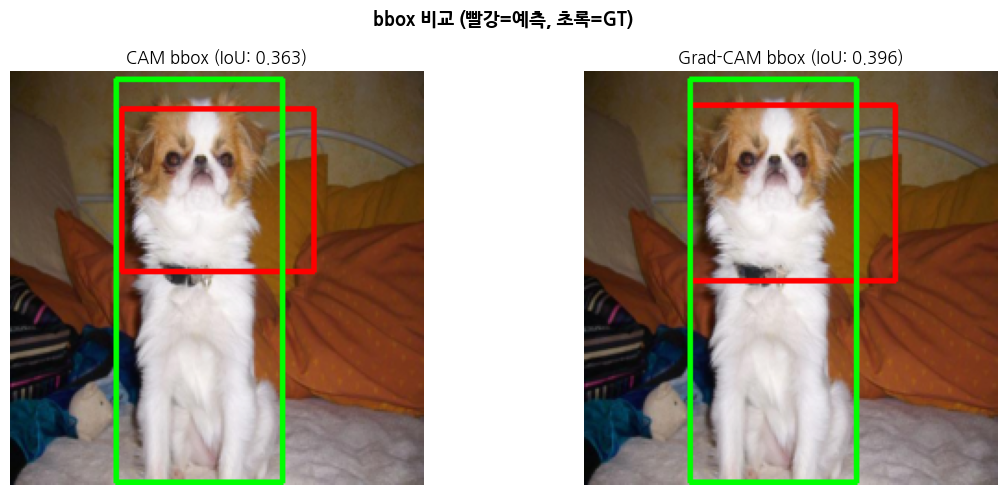

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('bbox 비교 (빨강=예측, 초록=GT)', fontsize=13, fontweight='bold')

for ax, pred_bbox, title, iou_val in zip(
    axes,
    [bbox, grad_cam_bbox],
    [f'CAM bbox (IoU: {iou_cam:.3f})', f'Grad-CAM bbox (IoU: {iou_grad_cam:.3f})'],
    [iou_cam, iou_grad_cam],
):
    img_vis = orig_img.copy()
    if pred_bbox:
        cv2.rectangle(img_vis, (pred_bbox[0], pred_bbox[1]),
                      (pred_bbox[2], pred_bbox[3]), (255, 0, 0), 2)
    cv2.rectangle(img_vis, (ground_truth[0], ground_truth[1]),
                  (ground_truth[2], ground_truth[3]), (0, 255, 0), 2)
    ax.imshow(img_vis)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

### CAM vs Grad-CAM 비교 결론

**(1) CAM 대비 Grad-CAM의 장점**

- CAM은 GAP 레이어가 반드시 포함된 구조에서만 적용이 가능해 모델 설계에 제약이 생기는 반면, Grad-CAM은 임의의 레이어에 gradient를 흘려보내는 방식이라 구조 변경 없이 모든 CNN 모델에 적용 가능하다는 장점이 있다.

- layer1~4처럼 원하는 레이어를 선택해 다해상도 분석이 가능하므로, 저수준 텍스처부터 고수준 의미 특징까지 단계별로 모델의 판단 근거를 해석할 수 있다.


**(2) IoU & 바운딩 박스**
- CAM IoU `0.363` vs Grad-CAM IoU `0.396`

- CAM은 예측된 바운딩 박스가 GT 중앙에서 왼쪽으로 치우쳐 있다. 히트맵이 얼굴과 가슴 부위에 집중됐고, 세로 폭도 짧아서 GT와 겹치는 면적이 상대적으로 적다.

- Grad-CAM은 예측된 바운딩 박스가 세로로 조금 더 길고 GT 중심축에 더 가깝게 정렬돼 있다. layer4의 히트맵이 CAM보다 몸통 상단을 조금 더 넓게 커버한 결과로, IoU가 CAM보다 `0.033` 높게 나온 이유로 생각한다.

- 두 기법 모두 GT 하단(다리)을 놓친 이유는, Stanford Dogs 어노테이션 GT가 발끝까지 포함하는 반면 모델은 분류에 가장 유효한 특징인 얼굴·몸통에 집중하기 때문이다. 분류 레이블만으로 학습한 모델은 어디까지가 객체인지 파악하는 데 어려움을 겪는 것으로 보인다.

## 8. 추가 실험

CAM 기법에서 두 모델 `bias=True` vs `bias=False` 의 Accuracy & IoU trade-off 를 확인한다.

> **가설**: `bias=False` 모델은 분류 정확도가 약간 낮을 수 있지만,
> CAM의 공간 기여도(IoU)는 더 높게 나온다.
> bias가 클래스 점수에 공간 기여도와는 큰 상관이 없는 상수를 더하면 결과적으로 히트맵이 

In [38]:
# 하이퍼파라미터 설정
EXPERIMENT_SAMPLES = 1000    # IoU 계산에 사용할 샘플 수
BBOX_THRESHOLD = 0.5   # get_bbox threshold
NUM_EPOCHS = 10

bias_model_path = os.path.join(PROJECT_DIR, 'cam_model_bias_true.pt')
no_bias_model_path = os.path.join(PROJECT_DIR, 'cam_model_bias_false.pt')

In [39]:
print('=' * 55)
print('[ 모델 A ] fc bias=True')
print('=' * 55)
set_seed(42) # 개별 난수 고정
model_bias = build_model(use_bias=True, num_classes=num_classes, device=device)
model_bias # 모델 구조 확인

[ 모델 A ] fc bias=True


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [40]:
opt_bias = optim.SGD(model_bias.parameters(), lr=0.01, momentum=0.9) # 모델 A 학습
sch_bias = optim.lr_scheduler.StepLR(opt_bias, step_size=2, gamma=0.1)
train_model(model_bias, train_loader, valid_loader,
            nn.CrossEntropyLoss(), opt_bias, NUM_EPOCHS, scheduler=sch_bias)
torch.save(model_bias, bias_model_path)


Epoch 1/10 시작
  Step 50 - Loss: 3.1125
  Step 100 - Loss: 1.9471
  Step 150 - Loss: 1.8828
  Step 200 - Loss: 1.9224
  Step 250 - Loss: 2.1963
  Step 300 - Loss: 1.6225
  Step 350 - Loss: 2.2829
  Step 400 - Loss: 1.9807
  Step 450 - Loss: 1.0677
  Step 500 - Loss: 3.5103
  Step 550 - Loss: 1.2361
  Step 600 - Loss: 1.7334
  Step 650 - Loss: 1.6076
  Step 700 - Loss: 2.0251
  Step 750 - Loss: 1.6760
  Step 800 - Loss: 1.4070
  Step 850 - Loss: 1.3366
  Step 900 - Loss: 1.1951
  Step 950 - Loss: 1.2742
  Step 1000 - Loss: 1.8581
Train - Loss: 1.8545, Accuracy: 50.00%
Validation - Loss: 1.3999, Accuracy: 60.06%
  LR: 0.010000

Epoch 2/10 시작
  Step 50 - Loss: 1.5793
  Step 100 - Loss: 0.8950
  Step 150 - Loss: 0.4624
  Step 200 - Loss: 0.8767
  Step 250 - Loss: 1.2023
  Step 300 - Loss: 1.3781
  Step 350 - Loss: 0.5161
  Step 400 - Loss: 1.0233
  Step 450 - Loss: 0.7809
  Step 500 - Loss: 1.1143
  Step 550 - Loss: 2.0449
  Step 600 - Loss: 0.5265
  Step 650 - Loss: 0.7521
  Step 700 - Lo

In [41]:
print('=' * 55)
print('[ 모델 B ] fc bias=False')
print('=' * 55)
set_seed(42) # 개별 난수 고정
model_no_bias = build_model(use_bias=False, num_classes=num_classes, device=device)
model_no_bias # 모델 구조 확인

[ 모델 B ] fc bias=False


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [42]:
opt_no_bias = optim.SGD(model_no_bias.parameters(), lr=0.01, momentum=0.9) # 모델 B 학습
sch_no_bias = optim.lr_scheduler.StepLR(opt_no_bias, step_size=2, gamma=0.1)
train_model(model_no_bias, train_loader, valid_loader,
            nn.CrossEntropyLoss(), opt_no_bias, NUM_EPOCHS, scheduler=sch_no_bias)
torch.save(model_no_bias, no_bias_model_path)


Epoch 1/10 시작
  Step 50 - Loss: 3.3901
  Step 100 - Loss: 1.2973
  Step 150 - Loss: 1.7076
  Step 200 - Loss: 1.4754
  Step 250 - Loss: 1.5468
  Step 300 - Loss: 1.8390
  Step 350 - Loss: 1.2862
  Step 400 - Loss: 1.7622
  Step 450 - Loss: 2.3746
  Step 500 - Loss: 1.2440
  Step 550 - Loss: 1.8650
  Step 600 - Loss: 0.9802
  Step 650 - Loss: 1.9227
  Step 700 - Loss: 1.6495
  Step 750 - Loss: 0.7580
  Step 800 - Loss: 1.4595
  Step 850 - Loss: 1.1931
  Step 900 - Loss: 1.3447
  Step 950 - Loss: 1.5899
  Step 1000 - Loss: 1.4402
Train - Loss: 1.8427, Accuracy: 50.75%
Validation - Loss: 1.3757, Accuracy: 61.39%
  LR: 0.010000

Epoch 2/10 시작
  Step 50 - Loss: 1.1108
  Step 100 - Loss: 1.5473
  Step 150 - Loss: 1.0655
  Step 200 - Loss: 1.1418
  Step 250 - Loss: 1.2103
  Step 300 - Loss: 1.1306
  Step 350 - Loss: 0.8555
  Step 400 - Loss: 1.2546
  Step 450 - Loss: 0.8441
  Step 500 - Loss: 1.0935
  Step 550 - Loss: 0.4926
  Step 600 - Loss: 0.7055
  Step 650 - Loss: 1.0766
  Step 700 - Lo

In [43]:
acc_bias = compute_accuracy(model_bias, valid_loader, device)
acc_no_bias = compute_accuracy(model_no_bias, valid_loader, device)

print(f'Accuracy  bias=True  : {acc_bias*100:.2f}%')
print(f'Accuracy  bias=False : {acc_no_bias*100:.2f}%')

Accuracy  bias=True  : 78.87%)
Accuracy  bias=False : 78.68%


In [44]:
print(f'IoU 계산 중... (샘플 {EXPERIMENT_SAMPLES}개)')
iou_bias = compute_mean_iou(model_bias,    valid_dataset, EXPERIMENT_SAMPLES, BBOX_THRESHOLD, device)
iou_no_bias = compute_mean_iou(model_no_bias, valid_dataset, EXPERIMENT_SAMPLES, BBOX_THRESHOLD, device)

print(f'Mean IoU  bias=True : {iou_bias:.4f}')
print(f'Mean IoU  bias=False : {iou_no_bias:.4f}')

IoU 계산 중... (샘플 1000개)
Mean IoU  bias=True : 0.2715
Mean IoU  bias=False : 0.2642


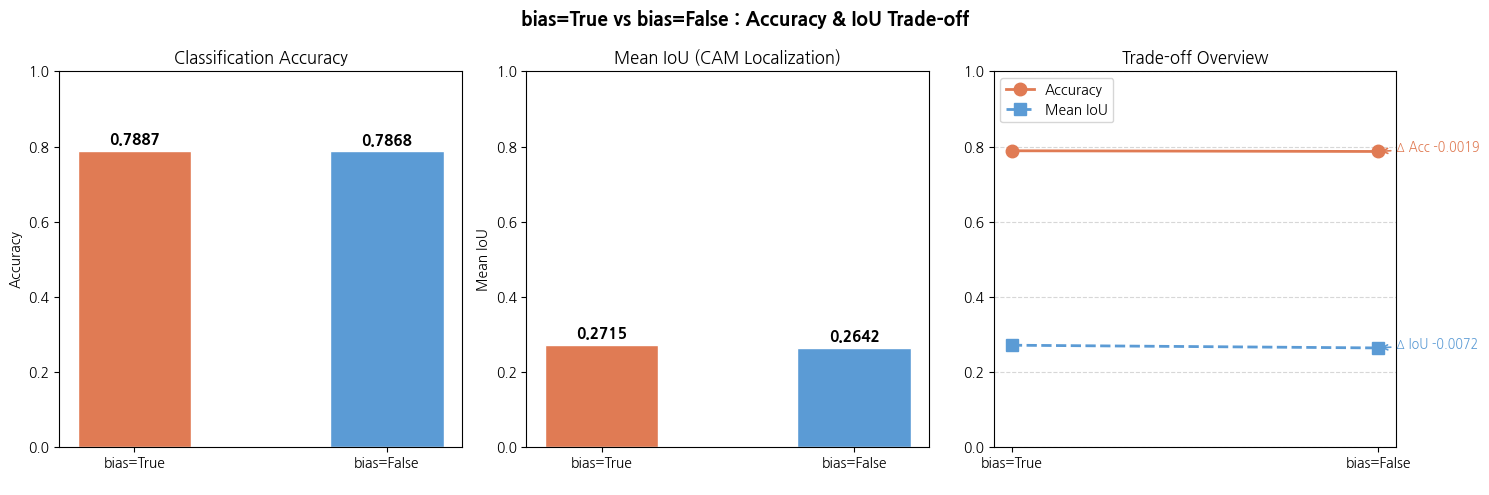


                        bias=True   bias=False  Δ (False-True)
--------------------------------------------------------------
Accuracy                   0.7887       0.7868         -0.0019
Mean IoU                   0.2715       0.2642         -0.0072


In [45]:
plot_tradeoff(acc_bias, acc_no_bias, iou_bias, iou_no_bias)

**1. Classification Accuracy**: 에폭 10회, 샘플 1000개 기준에서 두 모델의 분류 성능은 사실상 동일함을 알 수 있다. 이는 CAM 논문에서 서술한 바와 같다.

**2. Mean IoU**: bias=True 0.2715, bias=False 0.2642 이고 차이는 −0.0072로 bias=True가 소폭 높다.

**3. Trade-off Overview**: Accuracy는 거의 수평이고, IoU도 bias=True 쪽이 미세하게 높다. 두 지표 모두 bias=False로 전환했을 때 개선되지 않았다. 가설로 설정한 bias=False가 localization에 유리하다는 방향이 에폭 10회, 샘플 1000개 조건에서 기각되었다.

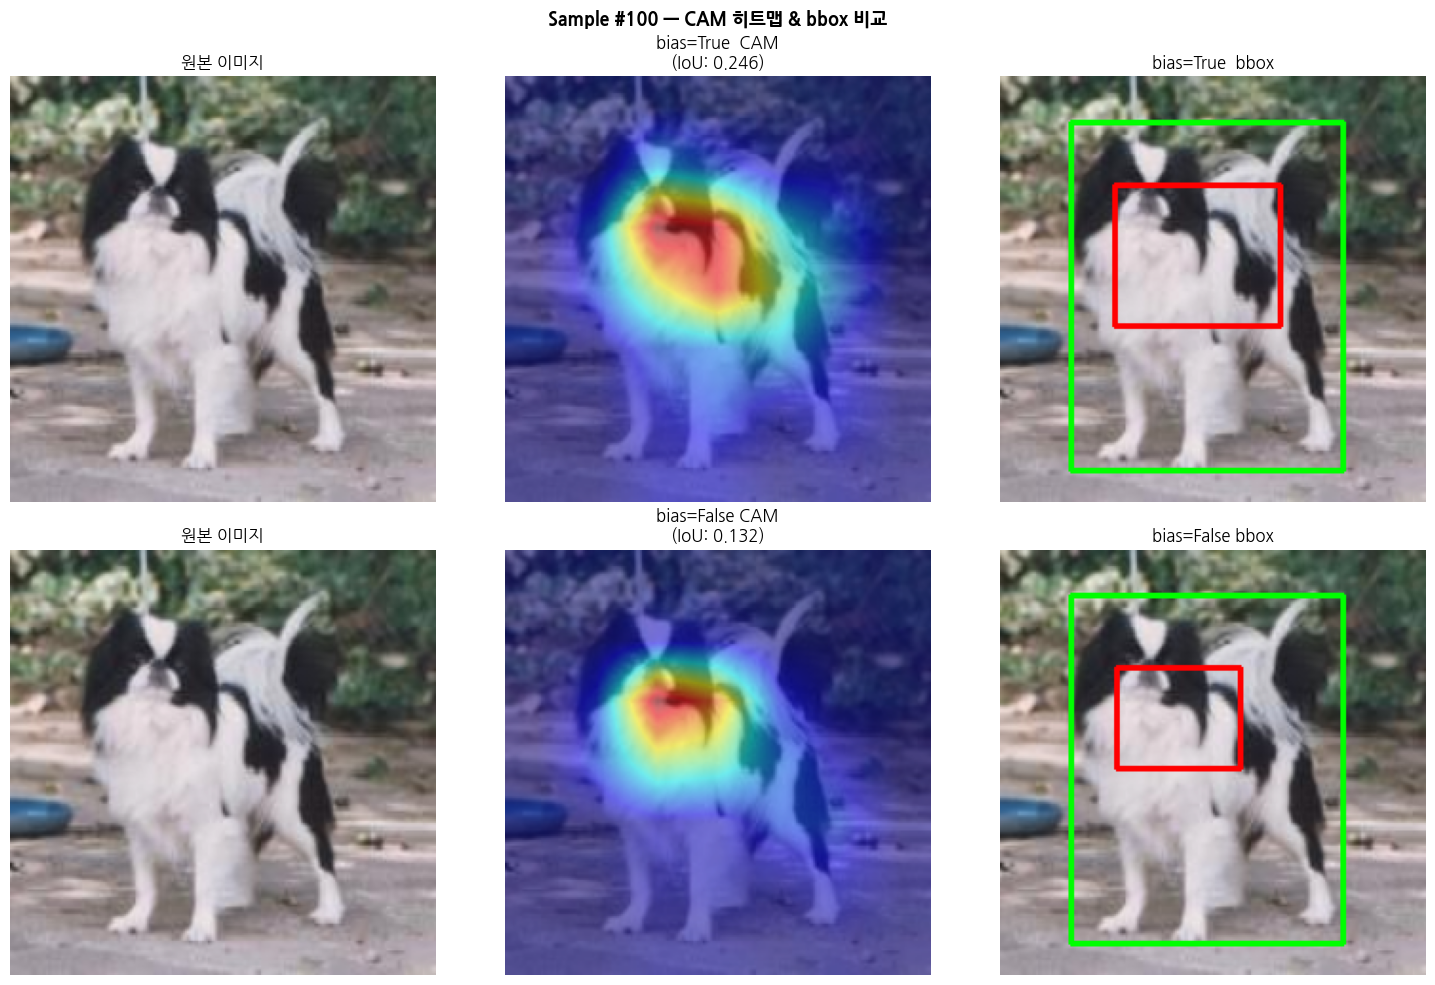

bias=True IoU: 0.2460
bias=False IoU: 0.1316
IoU 차이 : -0.1144


In [46]:
# 동일 샘플에 대해 두 모델의 CAM 히트맵을 비교
COMPARE_IDX = 100 # 샘플 인덱스

image, _, ground_bbox = valid_dataset[COMPARE_IDX]
sample_img  = image.unsqueeze(0).to(device)
orig = unnormalize(image)
ground_truth_box = tuple(int(x) for x in ground_bbox)

cam_b = generate_cam(model_bias,    sample_img)
cam_nb = generate_cam(model_no_bias, sample_img)

cam_b_resized = cv2.resize(cam_b,  (orig.shape[1], orig.shape[0]))
cam_nb_resized = cv2.resize(cam_nb, (orig.shape[1], orig.shape[0]))

bbox_b = get_bbox(cam_b_resized,  threshold_ratio=BBOX_THRESHOLD)
bbox_nb = get_bbox(cam_nb_resized, threshold_ratio=BBOX_THRESHOLD)

iou_b = get_iou(bbox_b,  ground_truth_box)
iou_nb = get_iou(bbox_nb, ground_truth_box)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'Sample #{COMPARE_IDX} — CAM 히트맵 & bbox 비교', fontsize=13, fontweight='bold')

titles = [
    ['원본 이미지', f'bias=True  CAM\n(IoU: {iou_b:.3f})',  f'bias=True  bbox'],
    ['원본 이미지', f'bias=False CAM\n(IoU: {iou_nb:.3f})', f'bias=False bbox'],
]

for row, (model_cam, cam_r, pred_bb, iou_val) in enumerate([
    (model_bias, cam_b_resized, bbox_b, iou_b),
    (model_no_bias, cam_nb_resized, bbox_nb, iou_nb),
]):
    # 원본
    axes[row][0].imshow(orig)
    axes[row][0].set_title(titles[row][0])
    axes[row][0].axis('off')

    # CAM overlay
    axes[row][1].imshow(overlay(cam_r, orig))
    axes[row][1].set_title(titles[row][1])
    axes[row][1].axis('off')

    # bbox 비교 (파랑=예측, 초록=GT)
    img_bb = orig.copy()
    if pred_bb:
        cv2.rectangle(img_bb, (pred_bb[0], pred_bb[1]), (pred_bb[2], pred_bb[3]), (255, 0, 0), 2)
    cv2.rectangle(img_bb,
                  (ground_truth_box[0], ground_truth_box[1]),
                  (ground_truth_box[2], ground_truth_box[3]), (0, 255, 0), 2)
    axes[row][2].imshow(img_bb)
    axes[row][2].set_title(titles[row][2])
    axes[row][2].axis('off')

plt.tight_layout()
plt.show()

print(f'bias=True IoU : {iou_b:.4f}')
print(f'bias=False IoU : {iou_nb:.4f}')
print(f'IoU 차이 : {iou_nb - iou_b:+.4f}')

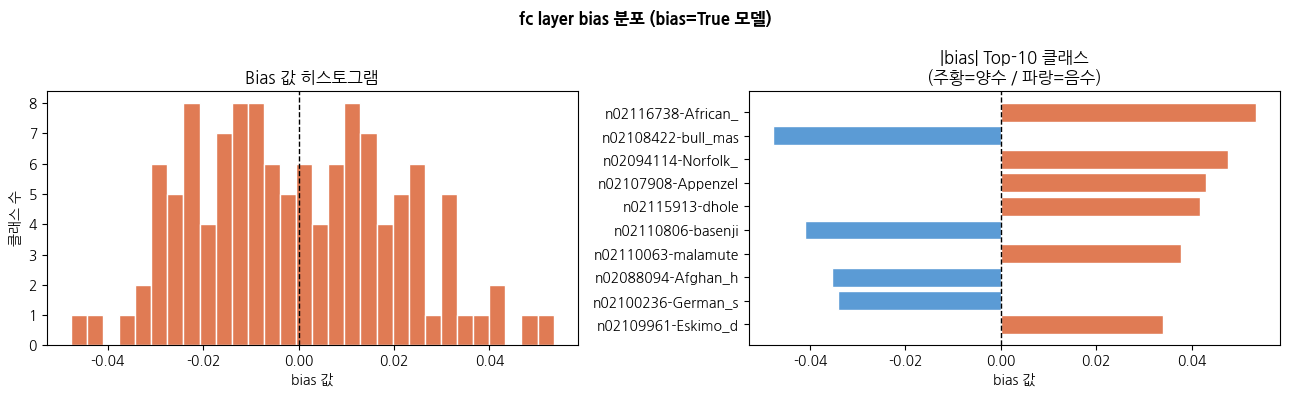

bias 평균 : -0.0004
bias 표준편차 : 0.0210
bias 최대 : 0.0535  (n02116738-African_hunting_dog)
bias 최소 : -0.0477  (n02108422-bull_mastiff)


In [47]:
# bias=True 모델에서 학습된 bias 값 분포를 확인
# bias가 클수록 공간 기여도(feature map)와 무관하게 점수를 올리는 클래스가 많다는 의미
bias_values = model_bias.fc.bias.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('fc layer bias 분포 (bias=True 모델)', fontsize=12, fontweight='bold')

axes[0].hist(bias_values, bins=30, color='#E07B54', edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Bias 값 히스토그램')
axes[0].set_xlabel('bias 값')
axes[0].set_ylabel('클래스 수')

# 절댓값 기준 Top-10 클래스
top10_idx = np.argsort(np.abs(bias_values))[::-1][:10]
top10_val = bias_values[top10_idx]
top10_lbl = [train_dataset.classes[i][:18] for i in top10_idx]   # 이름 길이 제한

bar_colors = ['#E07B54' if v > 0 else '#5B9BD5' for v in top10_val]
axes[1].barh(top10_lbl[::-1], top10_val[::-1], color=bar_colors[::-1], edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('|bias| Top-10 클래스\n(주황=양수 / 파랑=음수)')
axes[1].set_xlabel('bias 값')

plt.tight_layout()
plt.show()

print(f'bias 평균 : {bias_values.mean():.4f}')
print(f'bias 표준편차 : {bias_values.std():.4f}')
print(f'bias 최대 : {bias_values.max():.4f}  ({train_dataset.classes[bias_values.argmax()]})')
print(f'bias 최소 : {bias_values.min():.4f}  ({train_dataset.classes[bias_values.argmin()]})')

### 추가 실험 결론

- bias 유무는 분류 성능에 영향을 주지 않는다. 에폭 2→5→10, 샘플 50→ 1000으로 실험 조건을 단계적으로 강화했음에도 Accuracy 차이는 최대 0.0019로, CAM 논문의 bias=0 설정이 성능에 무시할 수 있는 영향만 준다는 주장이 실험에서 일관되게 확인됐다.

- bias 유무는 localization 성능에도 유의미한 차이를 만들지 않는다. 모든 실험 조건에서 Mean IoU 차이가 0.01 미만이었고, 학습된 bias 절댓값이 최대 0.054로 작아 분류 점수에서 bias가 차지하는 비중 자체가 미미했다. 이론적으로 예측한 bias=False → 히트맵 정확도 향상 → IoU 개선 논리가 이 데이터셋과 모델 구조에서는 실험적으로 재현되지 않았다.

- 두 기법 모두 localization 절댓값이 0.27 정도로 낮으며, 이는 bias보다 Weakly Supervised Localization의 구조적 한계에서 기인한다. 위 CAM vs. Grad-CAM 비교에서 이미 한 차례 확인했듯 분류 레이블만으로 학습한 모델은 판별에 유효한 부위(얼굴·몸통)에 집중하고 GT가 포함하는 전신 영역을 커버하지 못하며, 이 한계는 에폭과 샘플 수를 늘려도 개선되지 않았음을 알 수 있었다.

## 회고

- 논문을 읽는 게 아직 충분히 익숙하지 않아 추가 실험을 어떻게 할지 고민하는 데 시간이 좀 걸렸다.

- 추가 실험에서 에폭을 2, 5로 늘렸음에도 가설과 상반되는 결과가 나왔는데, 어느 정도의 샘플을 추가해야 할지, 얼마나 더 학습을 많이 수행해야 할지, 또는 어떤 케이스를 살펴봐야 할지 정하는 기준을 더 알아봐야겠다는 생각이 들었다.

- IoU 지표는 GT와 모델이 예측한 바운딩 박스가 상대적으로 얼마나 겹치는지만 확인하기 때문에 threshold만 조정해도 높일 수 있다. 이런 점 때문에 얼마나 신뢰할 수 있는 지표인지 다소 의심이 된다.

- 참고 문헌:
  * [Zhou et al. (CAM), CVPR 2016](https://arxiv.org/abs/1512.04150)
  * [Selvaraju et al., ICCV 2017](https://arxiv.org/abs/1610.02391)